Nome: Thaís da Silva Ferreira

Previsão de Demanda em Mobilidade Urbana com RNNs
Neste trabalho, o objetivo é prever a quantidade de bicicletas alugadas na próxima hora usando modelos recorrentes. Para isso, serão comparadas três arquiteturas:
SimpleRNN, LSTM e GRU.

In [5]:
import pandas as pd  
import numpy as np 
import matplotlib.pyplot as plt 

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [6]:
df = pd.read_csv('hour.csv')
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [7]:
df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


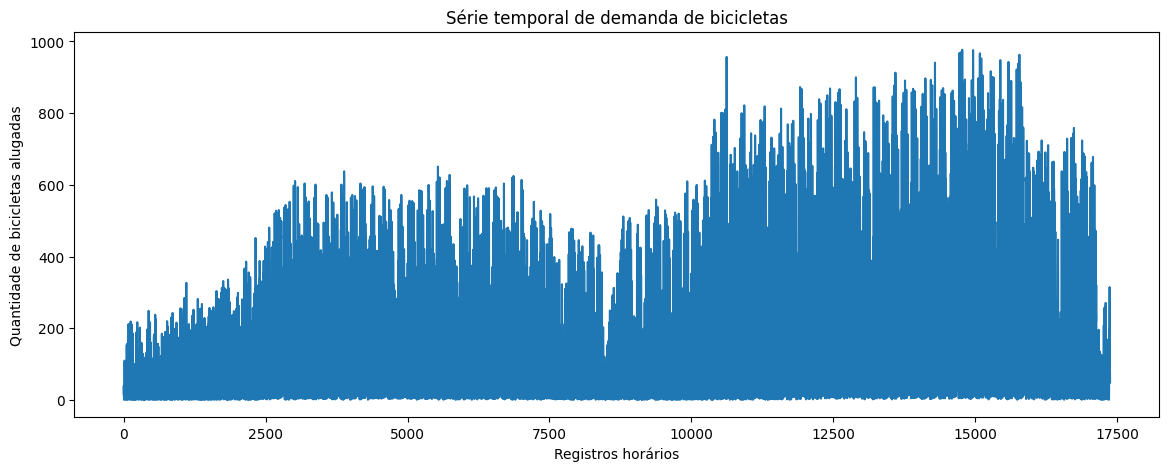

In [8]:
plt.figure(figsize=(14,5))
plt.plot(df['cnt'])
plt.title('Série temporal de demanda de bicicletas')
plt.xlabel('Registros horários')
plt.ylabel('Quantidade de bicicletas alugadas')
plt.show()

A visualização inicial mostra o comportamento da demanda de bicicletas ao longo do tempo. É possível perceber variações na quantidade de aluguéis conforme o horáreio, o dia, a estação do ano e as condições climáticas. Como os dados estão organizados por hora, ele são adequados para modelos de séries temporais.

In [10]:
df_model = df.drop(columns=['instant','dteday', 'casual', 'registered'])
df_model.head()

,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,16
1,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,40
2,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,32
3,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,13
4,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,1


In [21]:
X_dados = df_model.drop(columns=['cnt'])
y_dados = df_model[['cnt']]

In [23]:
scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_x.fit_transform(X_dados)
y_scaled = scaler_y.fit_transform(y_dados)

A normalização foi feita para deixar todas a variaveis em uma escala parecida. isso ajuda o treinamento das reeds neurais, evitando que variavéis com valores maiores tenham influência desproporcional no mnodelo.

In [24]:
def criar_janelas(X, y, janela=24):
    X_janelas = []
    y_janelas = []

    for i in range(janela, len(X)):
        X_janelas.append(X[i-janela:i])
        y_janelas.append(y[i])

    return np.array(X_janelas), np.array(y_janelas)

In [27]:
janela = 24

X, y = criar_janelas(X_scaled, y_scaled, janela)

print('Formato de X:', X.shape)
print('Formato de y:', y.shape)

Formato de X: (17355, 24, 12)
Formato de y: (17355, 1)


As janelas temporais transformam os dados em sequências. Neste caso, cada amostra possui informações das 24 horas anteriores, e o objetivo do modelo é prever a demanda da próxima hora. Essa estrutura é necessária para modelos recorrentes com SimpleRNN, LSTM e GRU.

In [28]:
tamanho_treino = int(len(X) * 0.8)

X_train = X[:tamanho_treino]
X_test = X[tamanho_treino:]

y_train = y[:tamanho_treino]
y_test = y[tamanho_treino:]

print('Treino', X_train.shape)
print('Treino', X_test.shape)

Treino (13884, 24, 12)
Treino (3471, 24, 12)


A divisão foi feita mantendo a ordem temporal dos dados. Os primeiros 80% foram usados para treinamento e os últimos 20% para teste. Isso é importante porque, em problemas de previsão temporal, o modelo deve aprender com o passado para prever o futuro.

In [29]:
model_rnn = Sequential()

model_rnn.add(SimpleRNN(
    64,
    activation="tanh",
    input_shape=(X_train.shape[1], X_train.shape[2])
))

model_rnn.add(Dropout(0.2))
model_rnn.add(Dense(1))

model_rnn.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mse"
)

history_rnn = model_rnn.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

c:\Users\Administrator\Documents\PUC Minas\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
348/348 ━━━━━━━━━━━━━━━━━━━━ 26s 34ms/step - loss: 0.0585 - val_loss: 0.0211
Epoch 2/20
348/348 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - loss: 0.0163 - val_loss: 0.0203
Epoch 3/20
348/348 ━━━━━━━━━━━━━━━━━━━━ 12s 34ms/step - loss: 0.0117 - val_loss: 0.0180
Epoch 4/20
348/348 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - loss: 0.0098 - val_loss: 0.0161
Epoch 5/20
348/348 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - loss: 0.0084 - val_loss: 0.0151
Epoch 6/20
348/348 ━━━━━━━━━━━━━━━━━━━━ 12s 34ms/step - loss: 0.0073 - val_loss: 0.0212
Epoch 7/20
348/348 ━━━━━━━━━━━━━━━━━━━━ 14s 40ms/step - loss: 0.0064 - val_loss: 0.0147
Epoch 8/20
348/348 ━━━━━━━━━━━━━━━━━━━━ 20s 38ms/step - loss: 0.0059 - val_loss: 0.0114
Epoch 9/20
348/348 ━━━━━━━━━━━━━━━━━━━━ 24s 45ms/step - loss: 0.0053 - val_loss: 0.0107
Epoch 10/20
348/348 ━━━━━━━━━━━━━━━━━━━━ 13s 37ms/step - loss: 0.0048 - val_loss: 0.0110
Epoch 11/20
348/348 ━━━━━━━━━━━━━━━━━━━━ 20s 35ms/step - loss: 0.0044 - val_loss: 0.0087
Epoch 12/20
348/348 ━━━━━━━━━━

In [30]:
model_lstm = Sequential()

model_lstm.add(LSTM(
    64,
    activation="tanh",
    input_shape=(X_train.shape[1], X_train.shape[2])
))

model_lstm.add(Dropout(0.2))
model_lstm.add(Dense(1))

model_lstm.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mse"
)

history_lstm = model_lstm.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20
348/348 ━━━━━━━━━━━━━━━━━━━━ 51s 68ms/step - loss: 0.0181 - val_loss: 0.0255
Epoch 2/20
348/348 ━━━━━━━━━━━━━━━━━━━━ 39s 62ms/step - loss: 0.0110 - val_loss: 0.0295
Epoch 3/20
348/348 ━━━━━━━━━━━━━━━━━━━━ 41s 61ms/step - loss: 0.0087 - val_loss: 0.0182
Epoch 4/20
348/348 ━━━━━━━━━━━━━━━━━━━━ 43s 66ms/step - loss: 0.0063 - val_loss: 0.0124
Epoch 5/20
348/348 ━━━━━━━━━━━━━━━━━━━━ 43s 70ms/step - loss: 0.0051 - val_loss: 0.0144
Epoch 6/20
348/348 ━━━━━━━━━━━━━━━━━━━━ 41s 66ms/step - loss: 0.0043 - val_loss: 0.0085
Epoch 7/20
348/348 ━━━━━━━━━━━━━━━━━━━━ 28s 76ms/step - loss: 0.0036 - val_loss: 0.0083
Epoch 8/20
348/348 ━━━━━━━━━━━━━━━━━━━━ 54s 112ms/step - loss: 0.0033 - val_loss: 0.0098
Epoch 9/20
348/348 ━━━━━━━━━━━━━━━━━━━━ 23s 61ms/step - loss: 0.0030 - val_loss: 0.0092
Epoch 10/20
348/348 ━━━━━━━━━━━━━━━━━━━━ 22s 64ms/step - loss: 0.0028 - val_loss: 0.0062
Epoch 11/20
348/348 ━━━━━━━━━━━━━━━━━━━━ 22s 62ms/step - loss: 0.0025 - val_loss: 0.0075
Epoch 12/20
348/348 ━━━━━━━━━

In [33]:
model_gru = Sequential()

model_gru.add(GRU(
    64,
    activation="tanh",
    input_shape=(X_train.shape[1], X_train.shape[2])
))

model_gru.add(Dropout(0.2))
model_gru.add(Dense(1))

model_gru.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mse"
)

history_gru = model_gru.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20
348/348 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - loss: 0.0196 - val_loss: 0.0288
Epoch 2/20
348/348 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - loss: 0.0120 - val_loss: 0.0233
Epoch 3/20
348/348 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - loss: 0.0099 - val_loss: 0.0177
Epoch 4/20
348/348 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - loss: 0.0066 - val_loss: 0.0108
Epoch 5/20
348/348 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - loss: 0.0051 - val_loss: 0.0124
Epoch 6/20
348/348 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - loss: 0.0041 - val_loss: 0.0084
Epoch 7/20
348/348 ━━━━━━━━━━━━━━━━━━━━ 12s 35ms/step - loss: 0.0035 - val_loss: 0.0104
Epoch 8/20
348/348 ━━━━━━━━━━━━━━━━━━━━ 20s 34ms/step - loss: 0.0033 - val_loss: 0.0064
Epoch 9/20
348/348 ━━━━━━━━━━━━━━━━━━━━ 21s 36ms/step - loss: 0.0030 - val_loss: 0.0059
Epoch 10/20
348/348 ━━━━━━━━━━━━━━━━━━━━ 20s 34ms/step - loss: 0.0028 - val_loss: 0.0077
Epoch 11/20
348/348 ━━━━━━━━━━━━━━━━━━━━ 21s 34ms/step - loss: 0.0028 - val_loss: 0.0060
Epoch 12/20
348/348 ━━━━━━━━━━━━━

In [34]:
pred_rnn = model_rnn.predict(X_test)
pred_lstm = model_lstm.predict(X_test)
pred_gru = model_gru.predict(X_test)

109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
109/109 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step


In [36]:
y_test_real = scaler_y.inverse_transform(y_test)

pred_rnn_real = scaler_y.inverse_transform(pred_rnn)
pred_lstm_real = scaler_y.inverse_transform(pred_lstm)
pred_gru_real = scaler_y.inverse_transform(pred_gru)

In [37]:
def avaliar_modelo(nome, y_real, y_pred):
    mae = mean_absolute_error(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    r2 = r2_score(y_real, y_pred)

    return {
        "Modelo": nome,
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2
    }

In [38]:
resultados = []

resultados.append(avaliar_modelo("SimpleRNN", y_test_real, pred_rnn_real))
resultados.append(avaliar_modelo("LSTM", y_test_real, pred_lstm_real))
resultados.append(avaliar_modelo("GRU", y_test_real, pred_gru_real))

df_resultados = pd.DataFrame(resultados)
df_resultados

,Modelo,MAE,RMSE,R²
0,SimpleRNN,87.608714,116.175310,0.722696
1,LSTM,57.333167,84.891535,0.851933
2,GRU,78.978933,107.247937,0.763677


A comparação foi feita usando as métricas MAE, RMSE e R². O MAE mostra o erro médio absoluto das previsões. O RMSE também mede erro, mas penaliza mais os erros grandes. O R² mostra o quanto o modelo consegue explicar a variação da demanda. O melhor modelo será aquele com menor MAE, menor RMSE e maior R².

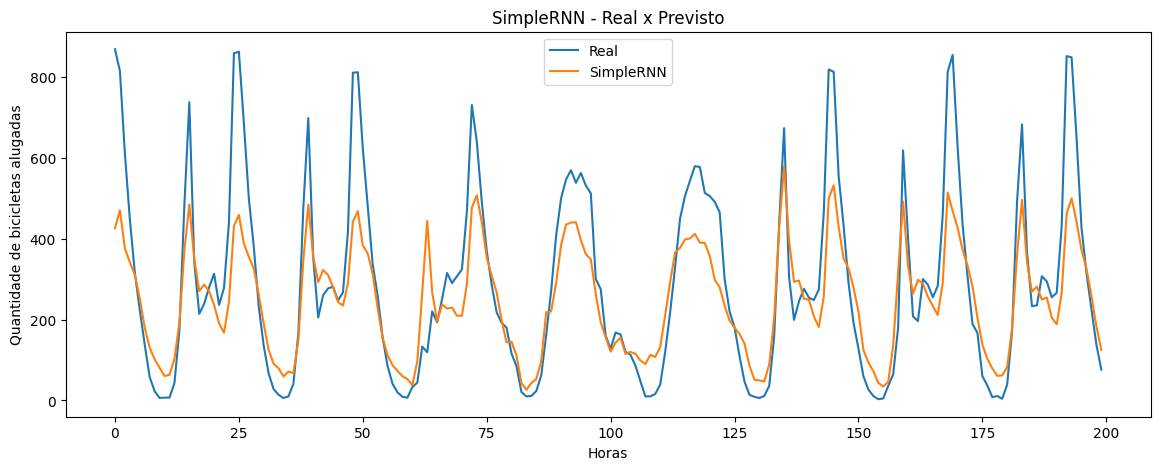

In [39]:
#SimnpleRNN

plt.figure(figsize=(14,5))
plt.plot(y_test_real[:200], label="Real")
plt.plot(pred_rnn_real[:200], label="SimpleRNN")
plt.title("SimpleRNN - Real x Previsto")
plt.xlabel("Horas")
plt.ylabel("Quantidade de bicicletas alugadas")
plt.legend()
plt.show()

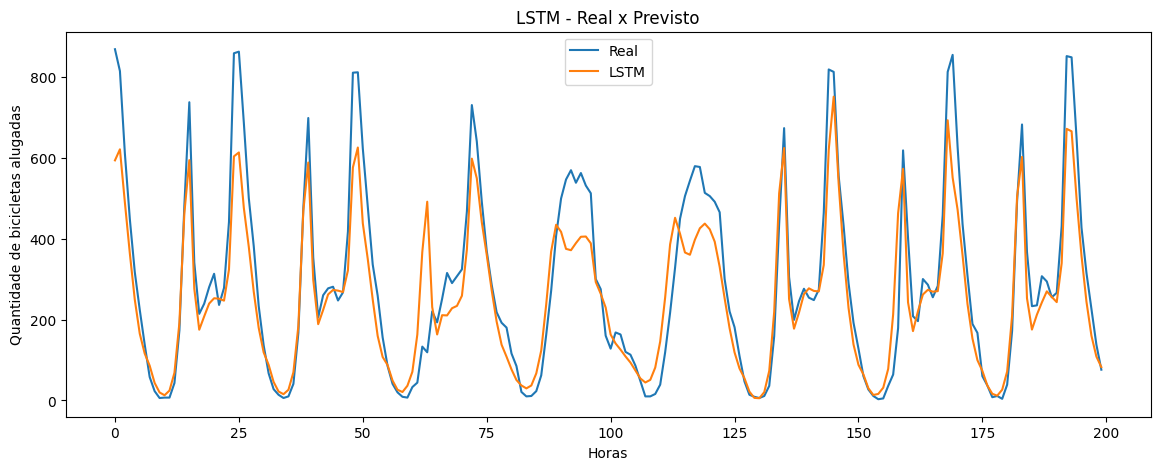

In [40]:
#LSTM

plt.figure(figsize=(14,5))
plt.plot(y_test_real[:200], label="Real")
plt.plot(pred_lstm_real[:200], label="LSTM")
plt.title("LSTM - Real x Previsto")
plt.xlabel("Horas")
plt.ylabel("Quantidade de bicicletas alugadas")
plt.legend()
plt.show()

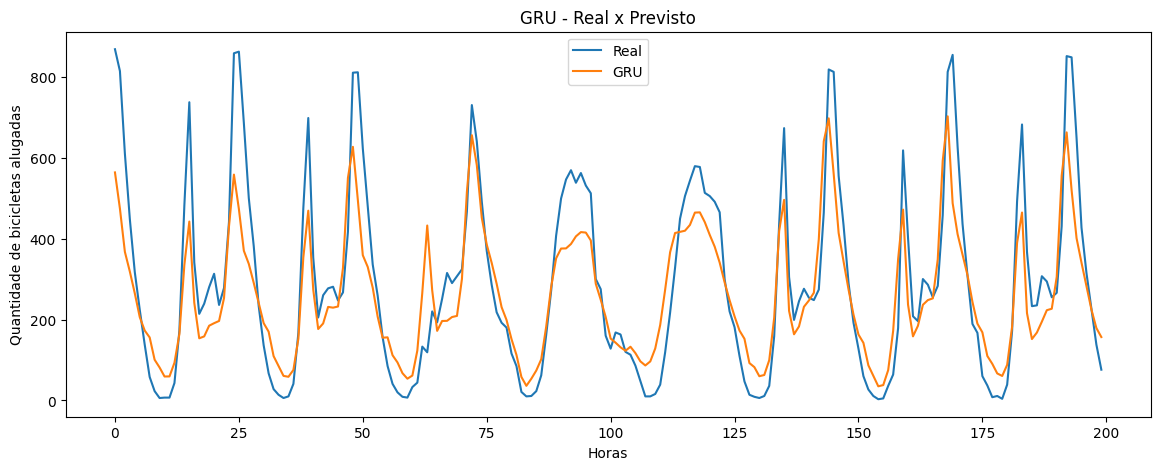

In [41]:
#GRU

plt.figure(figsize=(14,5))
plt.plot(y_test_real[:200], label="Real")
plt.plot(pred_gru_real[:200], label="GRU")
plt.title("GRU - Real x Previsto")
plt.xlabel("Horas")
plt.ylabel("Quantidade de bicicletas alugadas")
plt.legend()
plt.show()

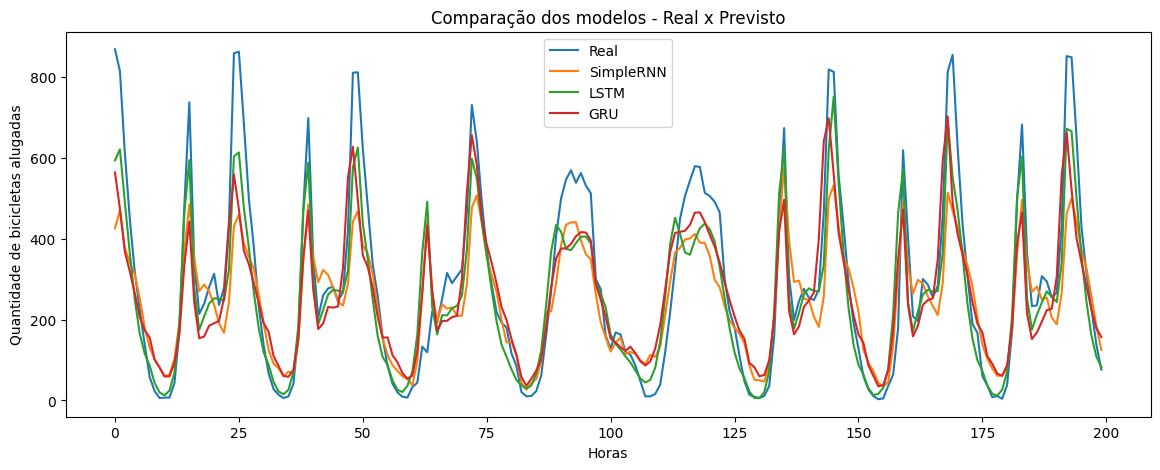

In [42]:
#Comparação geral

plt.figure(figsize=(14,5))
plt.plot(y_test_real[:200], label="Real")
plt.plot(pred_rnn_real[:200], label="SimpleRNN")
plt.plot(pred_lstm_real[:200], label="LSTM")
plt.plot(pred_gru_real[:200], label="GRU")
plt.title("Comparação dos modelos - Real x Previsto")
plt.xlabel("Horas")
plt.ylabel("Quantidade de bicicletas alugadas")
plt.legend()
plt.show()

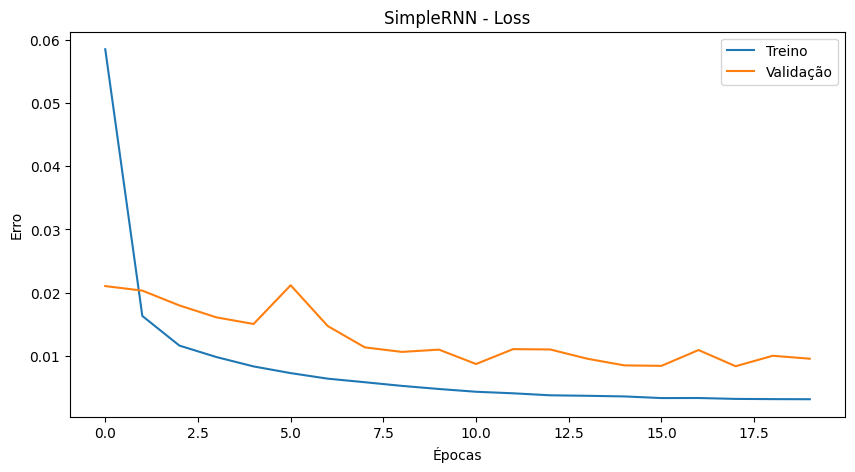

In [43]:
#Gráfico de perda dos modelos
#SimpleRNN

plt.figure(figsize=(10,5))
plt.plot(history_rnn.history["loss"], label="Treino")
plt.plot(history_rnn.history["val_loss"], label="Validação")
plt.title("SimpleRNN - Loss")
plt.xlabel("Épocas")
plt.ylabel("Erro")
plt.legend()
plt.show()

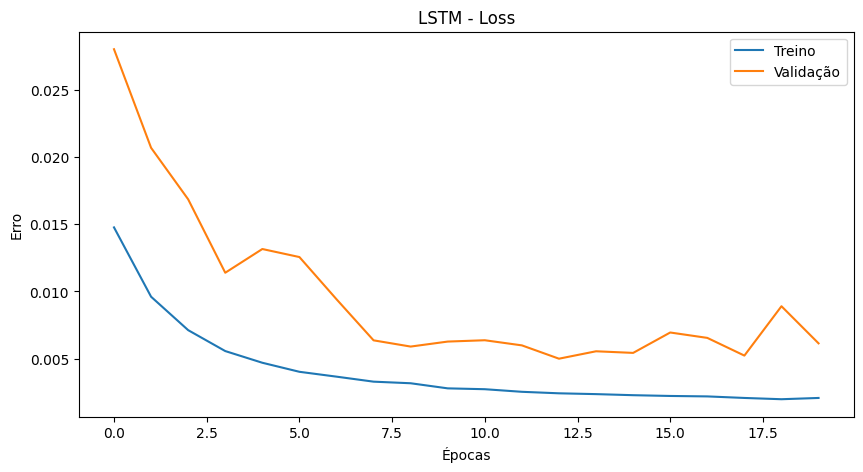

In [44]:
#LSTM

plt.figure(figsize=(10,5))
plt.plot(history_lstm.history["loss"], label="Treino")
plt.plot(history_lstm.history["val_loss"], label="Validação")
plt.title("LSTM - Loss")
plt.xlabel("Épocas")
plt.ylabel("Erro")
plt.legend()
plt.show()

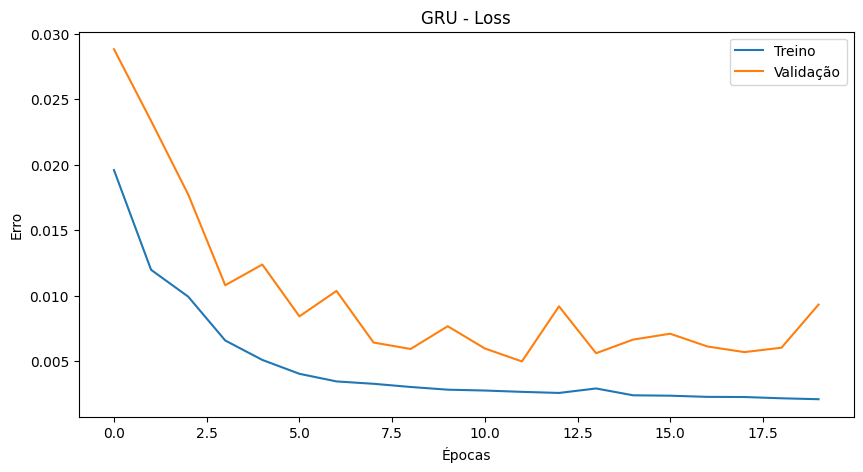

In [45]:
plt.figure(figsize=(10,5))
plt.plot(history_gru.history["loss"], label="Treino")
plt.plot(history_gru.history["val_loss"], label="Validação")
plt.title("GRU - Loss")
plt.xlabel("Épocas")
plt.ylabel("Erro")
plt.legend()
plt.show()

Neste trabalho, foi desenvolvido um estudo de previsão de demanda em mobilidade urbana usando redes neurais recorrentes. O objetivo foi prever a quantidade de bicicletas alugadas na próxima hora, auxiliando decisões como reposicionamento de bicicletas, planejamento de equipes e antecipação de horários de pico.

O dataset utilizado foi o Bike Sharing Dataset, que contém registros horários de aluguel de bicicletas e variáveis temporais e climáticas, como hora, mês, dia da semana, temperatura, umidade, clima e velocidade do vento.

No pré-processamento, foram removidas colunas que não seriam úteis ou que poderiam causar vazamento de dados, como `instant`, `dteday`, `casual` e `registered`. Em seguida, os dados foram normalizados com MinMaxScaler para facilitar o treinamento das redes neurais.

Para transformar o problema em uma série temporal, foram criadas janelas com as últimas 24 horas de dados, permitindo que os modelos usassem o histórico recente para prever a demanda da próxima hora.

Foram construídos e comparados três modelos recorrentes: SimpleRNN, LSTM e GRU. A SimpleRNN é mais simples, mas pode ter dificuldade com dependências longas. A LSTM é mais robusta para séries temporais, enquanto a GRU apresenta desempenho semelhante com menor complexidade.

A comparação dos modelos foi feita usando MAE, RMSE e R², além de gráficos Real × Previsto. Essas métricas permitiram avaliar qual modelo teve menor erro e melhor capacidade de acompanhar os padrões da demanda.

Como limitação, os modelos dependem da qualidade dos dados e não consideram fatores externos, como eventos, greves, obras ou mudanças inesperadas no comportamento dos usuários. Mesmo assim, a solução pode apoiar decisões operacionais em sistemas de bicicletas compartilhadas, melhorando a disponibilidade do serviço e reduzindo problemas em horários de pico.
